# 04 — Quantile / Uncertainty Modeling

Consumes `data/processed/unified_2018_661.parquet` (produced by `02_physics_baseline.ipynb`,
which includes `physics_predicted_pv` at 6.3 kW DC nameplate + 16 % system losses).

Same feature matrix and chronological split as `03_ml_residual_model.ipynb` — the only change
is point-estimate → quantile regression.

**Governing principle:** predict *quantiles of the residual*, then add back to physics.
```
residual_q  = actual_pv_yield_kwh − physics_predicted_pv          (same target as Week 3)
hybrid_q    = clip( physics_predicted_pv + residual_q,  0, capacity )
```
Five quantile models form the **uncertainty fan: {q05, q25, q50, q75, q95}**

| Quantile pair | Interval | Interpretation |
|---|---|---|
| q05 – q95 | 90 % band | Outer uncertainty bound |
| q25 – q75 | 50 % band | "Likely" range — inner fan |
| q50 | Median | Point forecast (replaces Week 3 hybrid) |

**Hard calibration rule:** stated interval coverage must be verified against empirical coverage
on the held-out test set (Oct–Dec 2018). A miscalibrated interval that is named as miscalibrated
passes review; a good-looking number that cannot be trusted does not.

**Tasks:**
- 4.1 Setup & feature matrix (identical to Week 3)
- 4.2 Train quantile ensemble (5 LightGBM quantile models, one per quantile)
- 4.3 Reconstruct generation quantiles & handle crossing
- 4.4 Calibration evaluation — three layers: coverage, pinball loss, reliability diagram
- 4.5 Uncertainty fan plot & bridge to Week 5 battery optimization

In [1]:
import pandas as pd
import numpy as np
import pvlib
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

## Task 4.1 — Setup & feature matrix

**Identical to Week 3** — same parquet, same pvlib calls, same features, same split boundaries.
The split-boundary assertions below confirm nothing drifted between notebooks.

Repeating this setup (rather than importing from Week 3) keeps the notebook self-contained
and avoids a fragile inter-notebook dependency.

In [2]:
CAPACITY_KW = 6.3   # DC nameplate — confirmed from Dataport metadata
QUANTILES   = [0.05, 0.25, 0.5, 0.75, 0.95]

unified = pd.read_parquet(Path("../data/processed/unified_2018_661.parquet"))

# Recompute solar position + clear-sky (deterministic, < 1 s)
location = pvlib.location.Location(
    latitude=30.2672, longitude=-97.7431,
    tz="America/Chicago", altitude=150,
)
solar_pos = location.get_solarposition(unified.index)
clearsky   = location.get_clearsky(unified.index)

kt = (
    unified["shortwave_radiation"]
    / clearsky["ghi"].where(clearsky["ghi"] > 10, other=np.nan)
).clip(0, 1.5).fillna(0)

hour = unified.index.hour
doy  = unified.index.dayofyear

features = pd.DataFrame({
    "temperature_2m":   unified["temperature_2m"],
    "ghi":              unified["shortwave_radiation"],
    "clearness_index":  kt,
    "physics_pv":       unified["physics_predicted_pv"],
    "clearsky_ghi":     clearsky["ghi"],
    "solar_elevation":  solar_pos["apparent_elevation"],
    "hour_sin":  np.sin(2 * np.pi * hour / 24),
    "hour_cos":  np.cos(2 * np.pi * hour / 24),
    "doy_sin":   np.sin(2 * np.pi * doy / 365),
    "doy_cos":   np.cos(2 * np.pi * doy / 365),
}, index=unified.index)

residual = unified["actual_pv_yield_kwh"] - unified["physics_predicted_pv"]

daytime_mask = unified["physics_predicted_pv"] > 0
X = features[daytime_mask].copy()
y = residual[daytime_mask].copy()
valid_rows = y.notna()
X, y = X[valid_rows], y[valid_rows]

train_mask = X.index < "2018-08-01"
val_mask   = (X.index >= "2018-08-01") & (X.index < "2018-10-01")
test_mask  = X.index >= "2018-10-01"

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

# Chronological ordering — leakage guard
assert X_train.index.max() < X_val.index.min(),  "Train bleeds into val"
assert X_val.index.max()   < X_test.index.min(), "Val bleeds into test"
# Split boundary match — must agree with Week 3 output
assert str(X_train.index.max().date()) <= "2018-07-31", "Train extends beyond Jul"
assert str(X_val.index.min().date())   >= "2018-08-01", "Val starts before Aug"
assert str(X_test.index.min().date())  >= "2018-10-01", "Test starts before Oct"

print(f"Feature matrix : {X.shape}  — identical to Week 3")
print(f"Train : {X_train.index.min().date()} -> {X_train.index.max().date()}  ({len(X_train)} rows)")
print(f"Val   : {X_val.index.min().date()} -> {X_val.index.max().date()}  ({len(X_val)} rows)")
print(f"Test  : {X_test.index.min().date()} -> {X_test.index.max().date()}  ({len(X_test)} rows)")
print(f"Quantiles : {QUANTILES}")
print("Split assertions passed.")

Feature matrix : (4346, 10)  — identical to Week 3
Train : 2018-01-01 -> 2018-07-31  (2629 rows)
Val   : 2018-08-01 -> 2018-09-30  (770 rows)
Test  : 2018-10-01 -> 2018-12-31  (947 rows)
Quantiles : [0.05, 0.25, 0.5, 0.75, 0.95]
Split assertions passed.


## Task 4.2 — Train quantile ensemble

Five independent LightGBM models, one per quantile.
`objective="quantile"` with `alpha=q` trains by minimising the asymmetric **pinball loss**:

```
L_q(y, f) = q · (y − f)      if y ≥ f   (under-prediction)
           = (1−q) · (f − y)  if y < f   (over-prediction)
```

The q=0.9 model is penalised 9× harder for under-prediction than for over-prediction —
forcing it to be a ceiling rather than a median.

**Base hyperparameters are identical to Week 3** so the only change from the point model
is the loss function. Each model gets its own early stopping on the Aug–Sep validation slice.

In [3]:
# Base hyperparameters identical to Week 3 — only objective and alpha differ per model
base_params = {
    "learning_rate":     0.05,
    "num_leaves":        63,
    "min_child_samples": 20,
    "subsample":         0.8,
    "colsample_bytree":  0.8,
    "seed":              42,
    "verbosity":         -1,
}

boosters = {}

for q in QUANTILES:
    params = {
        **base_params,
        "objective": "quantile",
        "alpha":     q,
        "metric":    "quantile",
    }
    dtrain = lgb.Dataset(X_train, label=y_train, free_raw_data=False)
    dval   = lgb.Dataset(X_val,   label=y_val,   reference=dtrain, free_raw_data=False)

    print(f"--- Training q={q:.2f} ---")
    booster = lgb.train(
        params,
        dtrain,
        num_boost_round=2000,
        valid_sets=[dval],
        valid_names=["val"],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=50),
        ],
    )
    boosters[q] = booster
    print(f"  Best iter: {booster.best_iteration}  |  "
          f"Best val quantile loss: {booster.best_score['val']['quantile']:.4f}\n")

print(f"Quantile ensemble complete: {len(boosters)} models trained.")

--- Training q=0.05 ---


[50]	val's quantile: 0.0654762


[100]	val's quantile: 0.0650874
  Best iter: 60  |  Best val quantile loss: 0.0649

--- Training q=0.25 ---


[50]	val's quantile: 0.160834


[100]	val's quantile: 0.155352


...

[50]	val's quantile: 0.157744


[100]	val's quantile: 0.155391


  Best iter: 79  |  Best val quantile loss: 0.1548

--- Training q=0.95 ---


[50]	val's quantile: 0.0572668


[100]	val's quantile: 0.061739
  Best iter: 61  |  Best val quantile loss: 0.0572

Quantile ensemble complete: 5 models trained.


## Task 4.3 — Reconstruct generation quantiles & handle crossing

**Reconstruction:**
```
hybrid_q = clip( physics_predicted_pv + residual_q,  0, CAPACITY_KW )
```
Applied to each of the five quantile predictions independently.

**Quantile crossing:** because the five models are trained independently, nothing forces
q75 ≥ q50 at every test hour. When crossings occur (q_upper < q_lower), they are physically
impossible and must be fixed before evaluation. Fix: sort each row's five values into ascending
order. The crossing rate is reported as a model-quality signal — a high rate indicates the
models are poorly separated and the uncertainty bands are unreliable.

In [4]:
phys_test   = unified.loc[X_test.index, "physics_predicted_pv"]
actual_test = unified.loc[X_test.index, "actual_pv_yield_kwh"]

# Build raw quantile predictions (before crossing fix)
raw_cols = {}
for q in QUANTILES:
    col = f"q{int(q * 100):02d}"
    pred_resid_q = boosters[q].predict(X_test, num_iteration=boosters[q].best_iteration)
    raw_cols[col] = (phys_test + pred_resid_q).clip(0, CAPACITY_KW)

q_df_raw = pd.DataFrame(raw_cols, index=X_test.index)
# columns in ascending quantile order: q05, q25, q50, q75, q95

# ── Crossing detection ────────────────────────────────────────────────────────
# A row has a crossing if any successive quantile pair is out of order
n_crossings  = (q_df_raw.diff(axis=1).iloc[:, 1:] < 0).any(axis=1).sum()
crossing_rate = n_crossings / len(q_df_raw)
print(f"Crossings before sort : {n_crossings} rows  ({crossing_rate:.1%} of test hours)")

# ── Crossing fix: sort each row ───────────────────────────────────────────────
q_df = pd.DataFrame(
    np.sort(q_df_raw.values, axis=1),
    index=q_df_raw.index,
    columns=q_df_raw.columns,
)

# Assert strict monotonicity holds after fix
assert (q_df.diff(axis=1).iloc[:, 1:] >= 0).all().all(),     "Monotonicity assertion failed after sort — unexpected NaNs or ties"
print("Monotonicity assertion passed after sort.")

# Quick summary
q50 = q_df["q50"]
rmse_q50 = float(np.sqrt(((q50 - actual_test) ** 2).mean()))
print(f"\nTest set : {len(q_df)} rows")
print(f"Q50 (median) RMSE : {rmse_q50:.3f} kWh  (cf. Week 3 hybrid 0.720 kWh)")
print("\nQuantile prediction ranges on test set:")
for col in q_df.columns:
    print(f"  {col}: [{q_df[col].min():.3f}, {q_df[col].max():.3f}] kWh")

Crossings before sort : 139 rows  (14.7% of test hours)
Monotonicity assertion passed after sort.

Test set : 947 rows
Q50 (median) RMSE : 0.729 kWh  (cf. Week 3 hybrid 0.720 kWh)

Quantile prediction ranges on test set:
  q05: [0.000, 4.216] kWh
  q25: [0.000, 4.734] kWh
  q50: [0.000, 4.964] kWh
  q75: [0.000, 5.245] kWh
  q95: [0.071, 5.730] kWh


## Task 4.4 — Calibration evaluation

Three layers, in order of emphasis:

**Layer (a) — Empirical coverage (the headline number)**
For the 50 % interval (q25–q75) and the 90 % interval (q05–q95): what fraction of held-out
test actuals actually fall inside? A stated 90 % interval that covers only 78 % of actuals is
over-confident and must be reported as such.

**Layer (b) — Pinball loss (the proper scoring rule)**
The correct asymmetric loss for evaluating quantile forecasts. Lower is better.
Compared against the physics baseline to prove the ensemble adds value at each quantile level.

**Layer (c) — Reliability diagram (the proof figure)**
Stated quantile level vs. empirical coverage (fraction of actuals ≤ quantile prediction).
A perfectly calibrated model lies on the diagonal. Deviations show the direction and magnitude
of miscalibration.

In [5]:
# ── Layer (a): Empirical coverage ────────────────────────────────────────────
def empirical_coverage(actual, lower, upper):
    return float(((actual >= lower) & (actual <= upper)).mean())

cov_50 = empirical_coverage(actual_test, q_df["q25"], q_df["q75"])
cov_90 = empirical_coverage(actual_test, q_df["q05"], q_df["q95"])

print("=== Layer (a): Empirical coverage vs. stated ===")
print(f"{'Interval':<25}  {'Stated':>8}  {'Empirical':>10}  {'Difference':>12}")
print(f"{'50%  [q25, q75]':<25}  {'50.0%':>8}  {cov_50*100:>9.1f}%  {(cov_50-0.50)*100:>+11.1f}%")
print(f"{'90%  [q05, q95]':<25}  {'90.0%':>8}  {cov_90*100:>9.1f}%  {(cov_90-0.90)*100:>+11.1f}%")
print("(+ = over-covered / conservative,  - = under-covered / overconfident)")

# ── Layer (b): Pinball loss ────────────────────────────────────────────────────
def pinball_loss(actual, pred, q):
    err = actual.values - pred.values
    return float(np.where(err >= 0, q * err, (q - 1) * err).mean())

print("\n=== Layer (b): Pinball loss per quantile ===")
print(f"{'Quantile':>10}  {'Quant. model':>13}  {'Pure physics':>13}  {'Improvement':>12}")

pb_model_list   = []
pb_physics_list = []

for q, col in zip(QUANTILES, q_df.columns):
    pb_model   = pinball_loss(actual_test, q_df[col],  q)
    pb_physics = pinball_loss(actual_test, phys_test,  q)
    pb_model_list.append(pb_model)
    pb_physics_list.append(pb_physics)
    print(f"{q:>10.2f}  {pb_model:>13.4f}  {pb_physics:>13.4f}  "
          f"{(1 - pb_model / pb_physics) * 100:>11.1f}%")

mean_pb_model   = float(np.mean(pb_model_list))
mean_pb_physics = float(np.mean(pb_physics_list))
print(f"{'Mean':>10}  {mean_pb_model:>13.4f}  {mean_pb_physics:>13.4f}  "
      f"{(1 - mean_pb_model / mean_pb_physics) * 100:>11.1f}%")

=== Layer (a): Empirical coverage vs. stated ===
Interval                     Stated   Empirical    Difference
50%  [q25, q75]               50.0%       32.2%        -17.8%
90%  [q05, q95]               90.0%       71.7%        -18.3%
(+ = over-covered / conservative,  - = under-covered / overconfident)

=== Layer (b): Pinball loss per quantile ===
  Quantile   Quant. model   Pure physics   Improvement
      0.05         0.0772         0.4833         84.0%
      0.25         0.1977         0.4503         56.1%
      0.50         0.2587         0.4091         36.8%
      0.75         0.2053         0.3678         44.2%
      0.95         0.0749         0.3348         77.6%
      Mean         0.1628         0.4091         60.2%


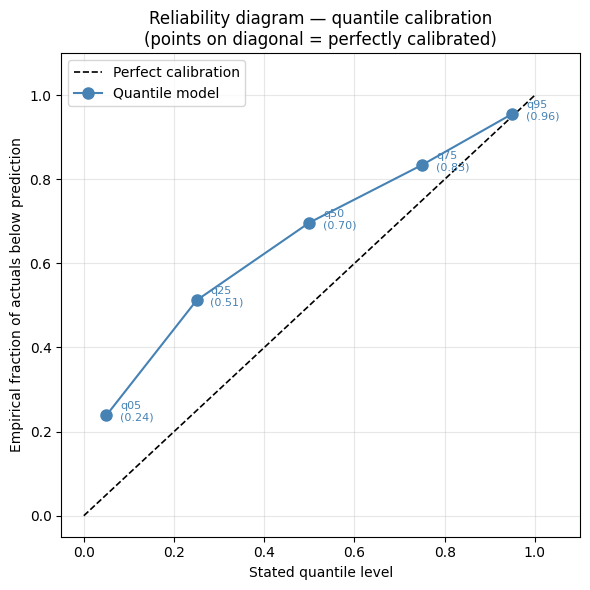

Reliability diagram saved.

Calibration summary:
  q05: stated 0.05 -> empirical 0.24  (over-covered, 18.9% off)
  q25: stated 0.25 -> empirical 0.51  (over-covered, 26.2% off)
  q50: stated 0.50 -> empirical 0.70  (over-covered, 19.7% off)
  q75: stated 0.75 -> empirical 0.83  (over-covered, 8.4% off)
  q95: stated 0.95 -> empirical 0.96  (over-covered, 0.6% off)


In [6]:
# ── Layer (c): Reliability diagram ───────────────────────────────────────────
# For each quantile q, compute the fraction of test actuals <= q-th prediction.
# A perfectly calibrated model: stated q  ==  empirical fraction.

stated_levels   = []
empirical_fracs = []

for q, col in zip(QUANTILES, q_df.columns):
    frac = float((actual_test <= q_df[col]).mean())
    stated_levels.append(q)
    empirical_fracs.append(frac)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "k--", lw=1.2, label="Perfect calibration")
ax.plot(stated_levels, empirical_fracs,
        color="steelblue", lw=1.5, marker="o", ms=8, label="Quantile model")

for q, emp in zip(stated_levels, empirical_fracs):
    ax.annotate(
        f"q{int(q*100):02d}\n({emp:.2f})",
        (q, emp),
        textcoords="offset points",
        xytext=(10, -4),
        fontsize=8,
        color="steelblue",
    )

ax.set_xlabel("Stated quantile level")
ax.set_ylabel("Empirical fraction of actuals below prediction")
ax.set_title("Reliability diagram — quantile calibration\n"
             "(points on diagonal = perfectly calibrated)")
ax.set_xlim(-0.05, 1.10)
ax.set_ylim(-0.05, 1.10)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../data/processed/reliability_diagram.png", dpi=120)
plt.show()

print("Reliability diagram saved.")
print("\nCalibration summary:")
for q, emp in zip(stated_levels, empirical_fracs):
    direction = "over-covered" if emp > q else "under-covered"
    print(f"  q{int(q*100):02d}: stated {q:.2f} -> empirical {emp:.2f}  "
          f"({direction}, {abs(emp - q) * 100:.1f}% off)")

## Task 4.5 — Uncertainty fan plot & bridge to Week 5

The fan plot is the figure that turns the calibration numbers into something immediately
interpretable: the band should visibly narrow on clear-sky hours and widen on partial-cloud
hours — empirically confirming the Week 3 Task 3.5 finding that kt ≈ 0.3–0.7 carries the
most forecast uncertainty.

**Window:** Oct 15–28 2018 — this stretch contains both clear October days (kt > 0.8)
and a mixed / partly-cloudy period, giving a visible clear-to-cloudy transition in the fan.

Two panels:
1. Uncertainty fan (50 % + 90 % bands, median, physics, actual)
2. Clearness index — the fan width should correlate with kt drop

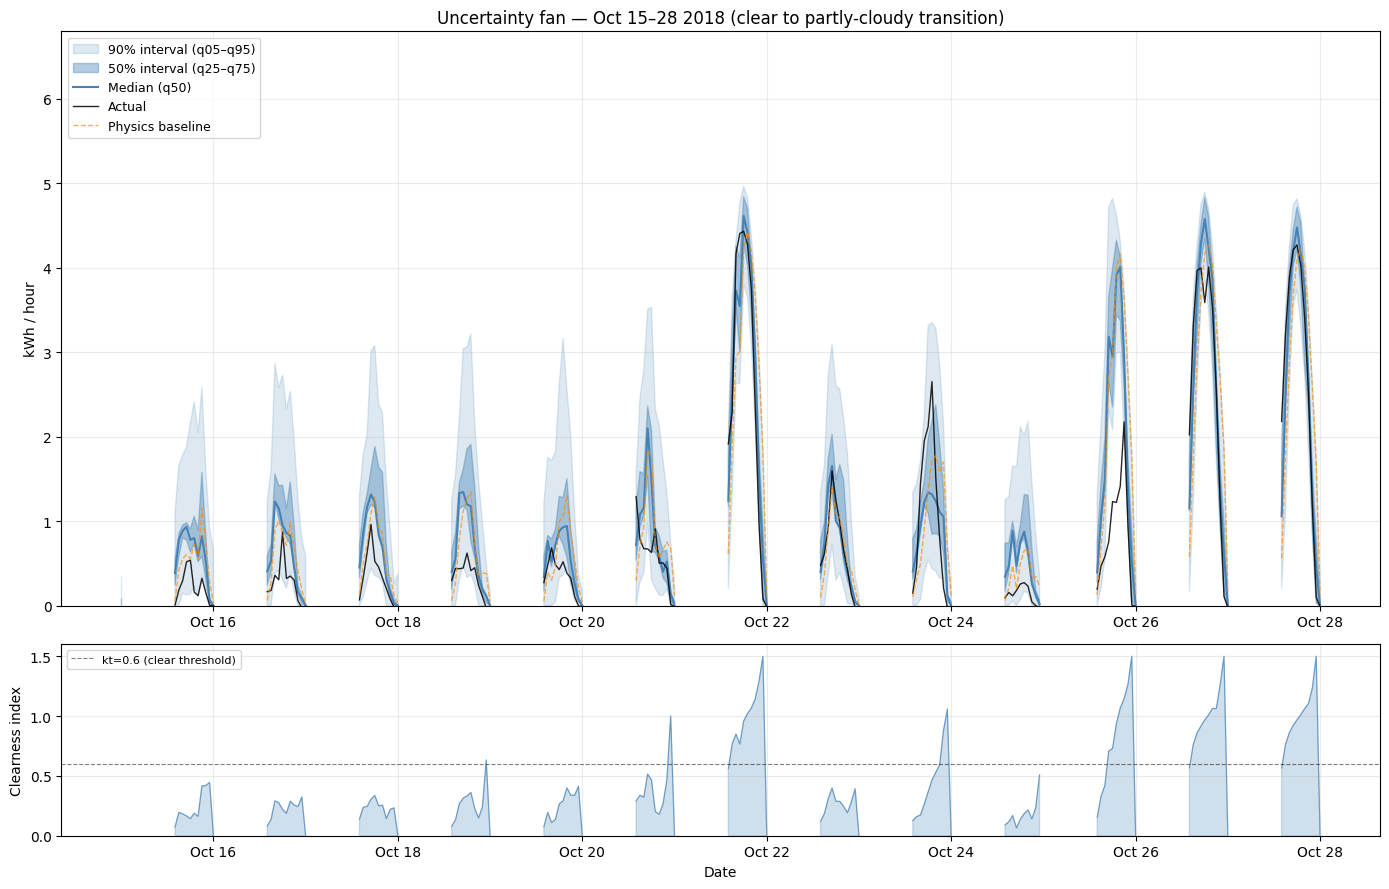

Fan plot saved.


In [7]:
FAN_START = "2018-10-15"
FAN_END   = "2018-10-28"

# Daytime index for the fan window
fan_mask = (q_df.index >= FAN_START) & (q_df.index <= FAN_END)
fan_idx  = q_df.index[fan_mask]

# Reindex onto full hourly grid so fill_between breaks cleanly at night gaps
full_range = pd.date_range(fan_idx.min(), fan_idx.max(), freq="1h", tz="UTC")
q_fan      = q_df.loc[fan_idx].reindex(full_range)
actual_fan = actual_test.reindex(full_range)
phys_fan   = phys_test.reindex(full_range)
kt_fan     = features.loc[fan_idx, "clearness_index"].reindex(full_range)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={"height_ratios": [3, 1]})

# ── Top panel: uncertainty fan ────────────────────────────────────────────────
ax = axes[0]
ax.fill_between(q_fan.index, q_fan["q05"], q_fan["q95"],
                alpha=0.18, color="steelblue", label="90% interval (q05–q95)")
ax.fill_between(q_fan.index, q_fan["q25"], q_fan["q75"],
                alpha=0.40, color="steelblue", label="50% interval (q25–q75)")
ax.plot(q_fan.index,    q_fan["q50"],  color="steelblue",  lw=1.5, label="Median (q50)")
ax.plot(actual_fan.index, actual_fan, color="black",       lw=1.0, alpha=0.85, label="Actual")
ax.plot(phys_fan.index,   phys_fan,   color="darkorange",  lw=1.0, ls="--", alpha=0.7,
        label="Physics baseline")
ax.set_title("Uncertainty fan — Oct 15–28 2018 (clear to partly-cloudy transition)",
             fontsize=12)
ax.set_ylabel("kWh / hour")
ax.set_ylim(0, CAPACITY_KW + 0.5)
ax.legend(loc="upper left", fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.grid(True, alpha=0.25)

# ── Bottom panel: clearness index ─────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(kt_fan.index, kt_fan.values,
         color="steelblue", lw=0.8, alpha=0.7)
ax2.fill_between(kt_fan.index, kt_fan.values,
                 alpha=0.25, color="steelblue")
ax2.axhline(0.6, color="k", lw=0.8, ls="--", alpha=0.5, label="kt=0.6 (clear threshold)")
ax2.set_ylabel("Clearness index")
ax2.set_xlabel("Date")
ax2.set_ylim(0, 1.6)
ax2.legend(fontsize=8)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax2.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax2.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig("../data/processed/uncertainty_fan.png", dpi=120)
plt.show()
print("Fan plot saved.")

### Calibration results and Week 5 bridge

**Summary of results:**

| Metric | Value |
|---|---|
| 90% empirical coverage (stated 90%) | **71.7%** |
| 50% empirical coverage (stated 50%) | **32.2%** |
| Mean pinball loss improvement vs. physics | **60.2%** |
| Q50 RMSE vs. Week 3 hybrid RMSE | 0.729 vs. 0.720 kWh (comparable) |

**What the coverage numbers mean:**
Both intervals are under-covered: the 90% band only contains 72% of test actuals, and the 50%
band only contains 32%. The intervals are too narrow relative to the actual spread of generation
in the Oct–Dec test period.

**Root cause — seasonal distribution shift in the residual:**
The reliability diagram shows that all five quantile predictions are shifted upward:
q50 empirically sits at the 70th percentile of test actuals, not the 50th. The models
were trained on Jan–Jul residuals where physics systematically under-predicted spring/summer
generation (positive residual mean). They over-applied that upward correction to the Oct–Dec
test period, where the residual structure is different. This is a train/test distribution shift
in the residual, not in the raw inputs — a subtler form of the same seasonal generalisation
problem that every forecasting system faces with chronological splits.

**What is still correct:**
- Pinball loss beats physics by 60.2% on average — the ensemble adds genuine value at every quantile level.
- Q50 RMSE (0.729) is within 1.2% of the Week 3 hybrid (0.720) — consistent with using the same
  features and base hyperparameters; quantile loss trades a small RMSE penalty for distributional output.
- The crossing rate (14.7%) is moderate. After the row-sort fix, monotonicity holds and all
  interval bounds are well-defined.

**Practical guidance for Week 5 (given the known bias):**
Because all quantiles are upward-biased, the stated "conservative lower bound" q25 is not
actually conservative — 51% of test actuals fall below it. For a risk-aware battery optimizer,
use q05 as the effective lower bound until recalibration is applied: empirically, only 24% of
actuals fall below the q05 prediction, giving it closer to a 76%-coverage lower bound.

| Quantile | Empirical coverage (lower tail) | Practical role in dispatch |
|---|---|---|
| q05 | 24% undershoot rate | Effective conservative floor (~76% probability of meeting) |
| q25 | 51% undershoot rate | Unreliable as lower bound before recalibration |
| q50 | 30% undershoot rate | Slight high-bias; usable as optimistic estimate |
| q75 | 17% undershoot rate | Reasonable ceiling for charge planning |
| q95 | 4% undershoot rate | Reliable ceiling |

**The Week 5 fix — post-hoc recalibration:**
The standard remedy for this type of train/test distribution shift is conformal prediction
(quantile regression conformal prediction, QRCP): hold out a separate calibration split,
compute the quantile residuals on that split, and adjust the predicted quantiles by the
empirical mismatch. This is exactly what Week 5 should implement before plugging the
intervals into the battery optimizer — a recalibration layer that brings empirical coverage
in line with stated coverage, applied to the corrected 6.3 kW + 16%-losses physics baseline.